# Laptops case study - solution

In [1]:
import pandas as pd
import seaborn as sns

# Section 1

## Get the data and examine it

In [2]:
data = pd.read_csv('laptops.csv')

In [3]:
data.head()

,brand,laptop_name,display_size,processor_type,graphics_card,disk_space,discount_price,old_price,ratings_5max
0,HP,Notebook 14-df0008nx,14.0,Intel Celeron N4000,Intel HD Graphics 600,64 GB (eMMC),1259.0,1259.0,0 / 5
1,Lenovo,IdeaPad 330S-14IKB,14.0,Intel Core i5-8250U,Intel UHD Graphics 620,1 TB HDD,1849.0,2099.0,3.3 / 5
2,Huawei,MateBook D Volta,14.0,Intel Core i5-8250U,NVIDIA GeForce MX150 (2 GB),256 GB SSD,2999.0,3799.0,0 / 5
3,Dell,Inspiron 15 3567,15.6,Intel Core i3-7020U,Intel HD Graphics 620,1 TB HDD,1849.0,1849.0,0 / 5
4,Asus,VivoBook 15 X510UR,15.6,Intel Core i7-8550U,NVIDIA GeForce 930MX (2 GB),1 TB HDD,2499.0,3149.0,0 / 5


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   brand           205 non-null    object 
 1   laptop_name     204 non-null    object 
 2   display_size    205 non-null    float64
 3   processor_type  205 non-null    object 
 4   graphics_card   205 non-null    object 
 5   disk_space      205 non-null    object 
 6   discount_price  205 non-null    float64
 7   old_price       205 non-null    float64
 8   ratings_5max    205 non-null    object 
dtypes: float64(3), object(6)
memory usage: 14.5+ KB


In [5]:
data.nunique()

brand               9
laptop_name       134
display_size       11
processor_type     26
graphics_card      52
disk_space         30
discount_price    124
old_price         104
ratings_5max       16
dtype: int64

### How many different laptop brands are there?

In [6]:
data.brand.nunique()

9

### What are the names and prices of the most and least expensive laptops?

In [7]:
# Sort by old_price. Then, select the first and last rows to get the least and most expensive rows.
data.sort_values('old_price').iloc[[0,-1]][['laptop_name','old_price']]

,laptop_name,old_price
108,Aspire 1 A114-31-C6WP,999.0
132,MacBook Pro (Retina + Touch Bar),12499.0


### How are the laptop prices distributed?

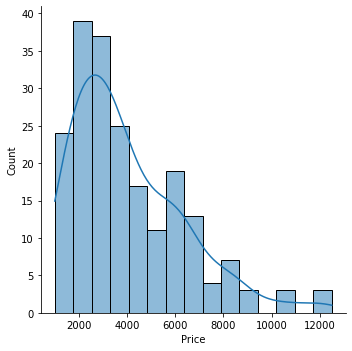

In [8]:
g = sns.displot(data=data, x='old_price', bins=15, kde=True)

for ax in g.axes.flat:
    ax.set(xlabel='Price')

#### Most prices are between 2k and 6k.
#### A few prices are more than 10k.

### What are the min, max, and mean display sizes?

In [9]:
data.display_size.describe()

count    205.000000
mean      14.579805
std        1.109458
min       12.000000
25%       13.300000
50%       14.000000
75%       15.600000
max       18.400000
Name: display_size, dtype: float64

#### The min is 12", the max is 18", and the mean is 14.57".

### What is the average price for each laptop brand?

In [10]:
# Group by brand and calculate average price
prices = data.groupby(['brand']).mean()[['old_price']]
prices = prices.reset_index().sort_values('old_price', ascending=False)
prices

,brand,old_price
7,MSI,9071.000000
1,Apple,7082.288158
8,Microsoft,5132.333333
5,Huawei,4040.666667
3,Dell,3872.029412
2,Asus,3393.090909
4,HP,3382.541667
0,Acer,2773.083333
6,Lenovo,2216.391304


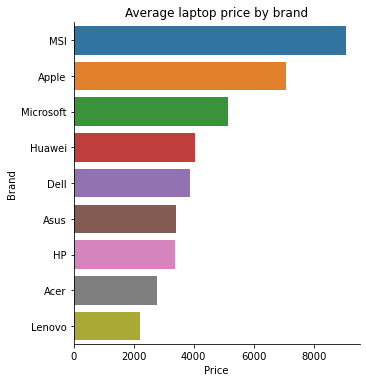

In [11]:
g = sns.catplot(data=prices, x='old_price', y='brand', kind='bar')

for ax in g.axes.flat:
    ax.set(title='Average laptop price by brand',
           ylabel='Brand',
           xlabel='Price')

#### The chart above shows the average price for each laptop brand.